<a href="https://colab.research.google.com/github/Juncalbh/03MIAR-Algoritmos-de-optimizacion/blob/main/Algoritmos_AG3_Juncal_Blanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Juncal Blanco <br>
Link:   https://colab.research.google.com/drive/1e_6fgP6-TYuAaY23UIJVQxr0HDnal3JJ?usp=sharing <br>
Github: https://github.com/Juncalbh/03MIAR-Algoritmos-de-optimizacion
<br>


#Carga de librerias

In [ ]:
!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps


In [ ]:
!pip install deprecated

#Carga de los datos del problema

In [ ]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x7a882350b350>)

In [ ]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [ ]:
Nodos

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [ ]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),



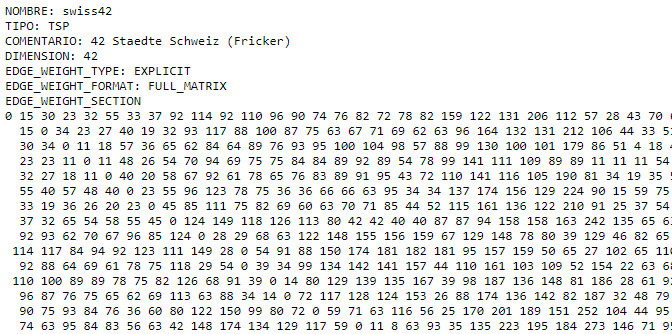

In [ ]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

#Funcionas basicas


In [ ]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 18, 23, 40, 2, 26, 17, 33, 13, 39, 14, 24, 32, 19, 5, 10, 28, 16, 25, 15, 34, 9, 27, 30, 31, 3, 20, 21, 37, 38, 1, 41, 12, 7, 29, 6, 35, 8, 11, 4, 36, 22]
5399


#BUSQUEDA ALEATORIA

In [ ]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 4, 22, 34, 2, 10, 38, 25, 11, 12, 31, 16, 35, 36, 15, 21, 9, 30, 17, 37, 7, 18, 6, 20, 13, 26, 5, 32, 14, 8, 23, 27, 41, 24, 39, 40, 29, 3, 19, 28, 33, 1]
Distancia     : 3707


#BUSQUEDA LOCAL

In [ ]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3707
Distancia Mejor Solucion Local: 3481


In [ ]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  30 , la mejor solución encontrada es: [0, 27, 2, 28, 9, 23, 41, 25, 11, 12, 6, 17, 36, 35, 31, 32, 3, 4, 1, 7, 37, 15, 16, 14, 19, 13, 5, 26, 18, 10, 8, 38, 22, 39, 24, 40, 21, 29, 30, 34, 33, 20]
Distancia     : 1676


#SIMULATED ANNEALING


In [ ]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

In [ ]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 17, 31, 32, 20, 34, 33, 22, 38, 39, 24, 40, 21, 30, 28, 27, 3, 35, 36, 37, 19, 13, 10, 23, 9, 29, 2, 4, 1, 5, 18, 8, 41, 25, 12, 11, 26, 6, 7, 14, 16, 15]
con una distancia total de 1997


#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


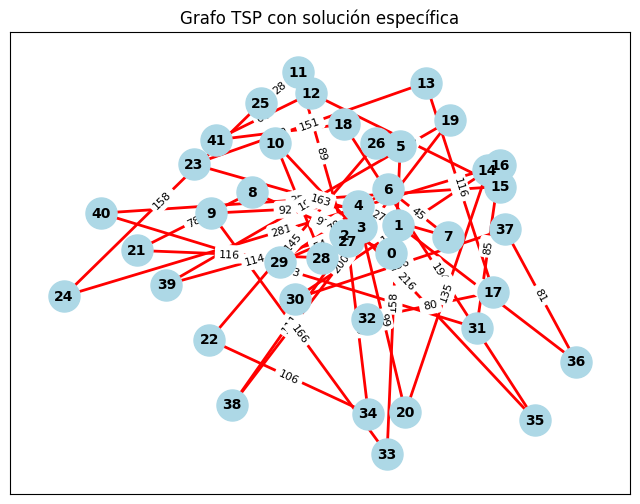

In [ ]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

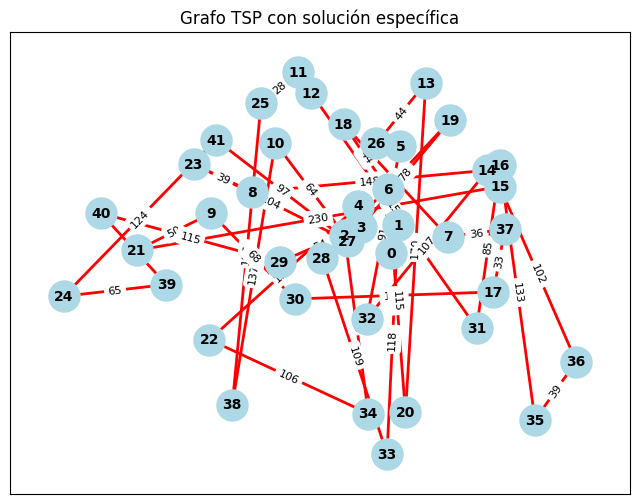

In [ ]:
plot_tsp_solution(problem.edge_weights, solucion)

# Búsqueda local con entornos variables

In [ ]:
import random

# --- Funciones Auxiliares para el TSP ---
def calcular_distancia(solucion, problem):
    distancia_total = 0
    for i in range(len(solucion) - 1):
        distancia_total += problem.get_weight(solucion[i], solucion[i+1])
    distancia_total += problem.get_weight(solucion[-1], solucion[0])
    return distancia_total

def generar_vecino(solucion, k):
    """Genera un vecino según el nivel de entorno k"""
    sol = list(solucion)
    if k == 1: # Intercambio (Swap)
        i, j = random.sample(range(len(sol)), 2)
        sol[i], sol[j] = sol[j], sol[i]
    elif k == 2: # Inversión de segmento (2-opt)
        i, j = sorted(random.sample(range(len(sol)), 2))
        sol[i:j] = reversed(sol[i:j])
    return sol

# --- Algoritmo VNS ---
def vns(problem, nodos, iteraciones=1000):
    # Solución inicial
    mejor_solucion = list(nodos)
    random.shuffle(mejor_solucion)
    mejor_distancia = calcular_distancia(mejor_solucion, problem)

    k_max = 2 # Número de entornos

    for _ in range(iteraciones):
        k = 1
        while k <= k_max:
            # 1. Agitación y Búsqueda Local (Simplificada)
            nueva_solucion = generar_vecino(mejor_solucion, k)
            nueva_distancia = calcular_distancia(nueva_solucion, problem)

            # 2. Decisión de movimiento
            if nueva_distancia < mejor_distancia:
                mejor_solucion = nueva_solucion
                mejor_distancia = nueva_distancia
                k = 1 # Se reinicia el entorno al mejorar
            else:
                k += 1 # Se pasa a un entorno más amplio

    return mejor_solucion, mejor_distancia

# Ejecución
sol_vns, dist_vns = vns(problem, Nodos)
print(f"Mejor distancia encontrada por VNS: {dist_vns}")

Mejor distancia encontrada por VNS: 1433


El algoritmo **VNS** es una metaheurística que se basa en la idea de cambiar sistemáticamente la estructura de la vecindad para escapar de los óptimos locales. Mientras que una búsqueda local simple se detiene cuando no encuentra mejoras en su entorno inmediato, VNS "salta" a entornos más amplios.

**Componentes clave:**
* **Entornos Variables:** Definimos varias formas de alterar la solución. Por ejemplo, `k=1` (intercambio de dos nodos) y `k=2` (inversión de un segmento de la ruta o 2-opt).
* **Agitación (Shaking):** Se genera una solución aleatoria dentro del entorno actual $k$. Esto sirve para "sacudir" la solución y sacarla del estancamiento.
* **Cambio de Entorno:** Si tras la agitación y la búsqueda local no se mejora la mejor solución global, el algoritmo pasa a un entorno $k+1$ (más agresivo). Si se encuentra una mejora, se reinicia al entorno más pequeño ($k=1$).

**Ventaja:** Es muy eficaz para problemas donde los óptimos locales están muy dispersos, ya que permite explorar zonas del espacio de búsqueda que un simple intercambio no alcanzaría.

# Recocido simulado

In [ ]:
import math

def recocido_simulado(problem, nodos, T_inicial=2000, cooling_rate=0.995, iteraciones=5000):
    # Solución inicial
    solucion_actual = list(nodos)
    random.shuffle(solucion_actual)
    distancia_actual = calcular_distancia(solucion_actual, problem)

    mejor_solucion = list(solucion_actual)
    mejor_distancia = distancia_actual

    T = T_inicial

    for i in range(iteraciones):
        # Generamos un vecino (entorno swap)
        nueva_solucion = generar_vecino(solucion_actual, 1)
        nueva_distancia = calcular_distancia(nueva_solucion, problem)

        # Diferencia de coste
        delta = nueva_distancia - distancia_actual

        # Criterio de aceptación
        if delta < 0 or random.random() < math.exp(-delta / T):
            solucion_actual = nueva_solucion
            distancia_actual = nueva_distancia

            # Actualizar récord histórico
            if distancia_actual < mejor_distancia:
                mejor_solucion = list(solucion_actual)
                mejor_distancia = distancia_actual

        # Enfriamiento
        T *= cooling_rate
        if T < 0.01: break

    return mejor_solucion, mejor_distancia

# Ejecución
sol_sa, dist_sa = recocido_simulado(problem, Nodos)
print(f"Mejor distancia encontrada por Recocido Simulado: {dist_sa}")

Mejor distancia encontrada por Recocido Simulado: 1663


### 2. Recocido Simulado (Simulated Annealing)

El **Recocido Simulado** es una metaheurística inspirada en el proceso físico de enfriamiento de los metales (recocido). Su característica principal es que **permite aceptar soluciones peores** de forma temporal para evitar quedar atrapado en óptimos locales.

**Lógica del algoritmo:**
1.  **Temperatura ($T$):** Al inicio, la temperatura es alta y el algoritmo es "valiente", aceptando casi cualquier cambio. A medida que $T$ baja, el algoritmo se vuelve más selectivo (conservador).
2.  **Criterio de Aceptación (Metrópolis):** * Si la nueva solución es mejor ($\Delta E < 0$), se acepta siempre.
    * Si la nueva solución es peor ($\Delta E > 0$), se acepta con una probabilidad $P = e^{-\frac{\Delta E}{T}}$.
3.  **Esquema de Enfriamiento:** En cada iteración, la temperatura se reduce según un factor de enfriamiento (ej. $0.99$).

**Ventaja:** Es excelente para "saltar" valles en la función de coste. Al final del proceso, cuando la temperatura es cercana a cero, el algoritmo se comporta como una búsqueda local pura, refinando la solución encontrada.